Installing scikit-learn...
Loading Excel file: /content/globalterrorismdb_2021Jan-June_1222dist.xlsx
Loaded rows: 4960 cols: 135
Numeric features: ['latitude', 'longitude', 'month', 'day']
Categorical features: ['country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'provstate', 'city']
Train/test shapes: (3968, 11) (992, 11)
Training cfg: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'sqrt'}
  -> f1=0.8080, time=0.9s
Training cfg: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 5, 'max_features': 'log2'}
  -> f1=0.8058, time=1.2s
Training cfg: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 10, 'max_features': 0.5}
  -> f1=0.8110, time=3.4s

Best cfg: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 10, 'max_features': 0.5} best f1: 0.810958904109589

Accuracy: 0.7913306451612904

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.

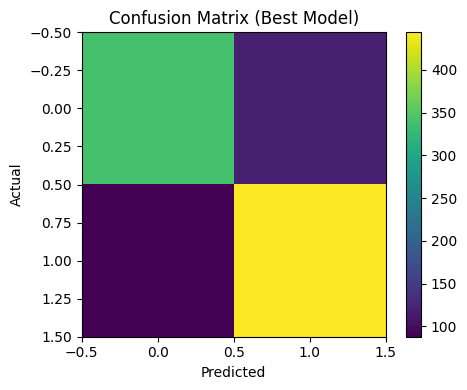


Saved tuned model to rf_terror_model_full_tuned_shap.joblib


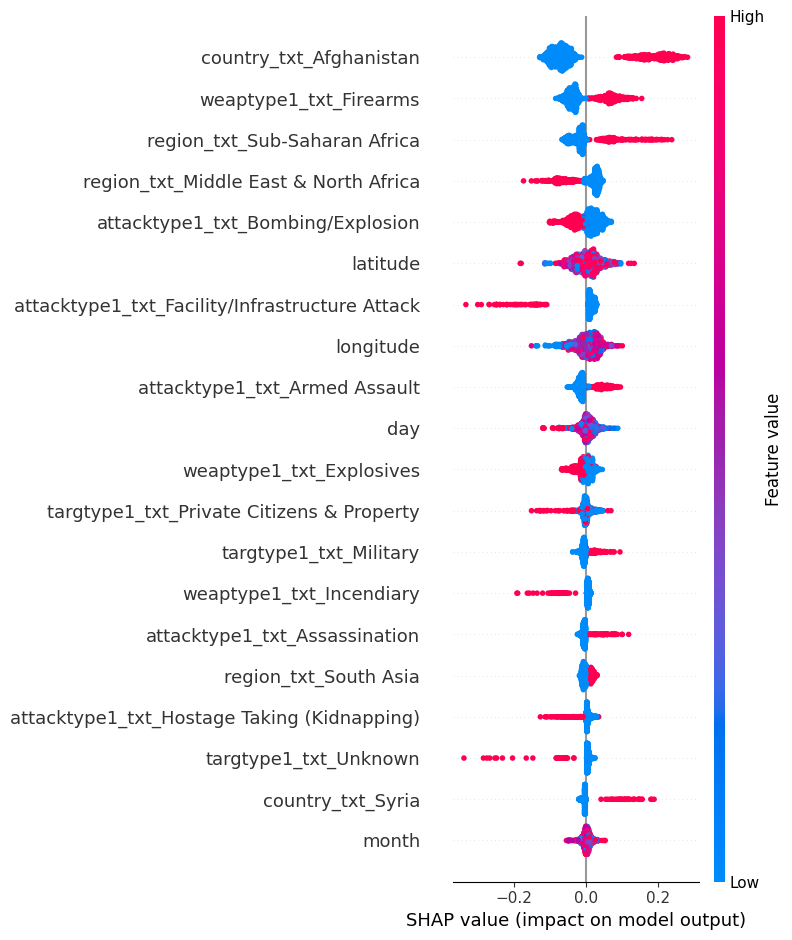

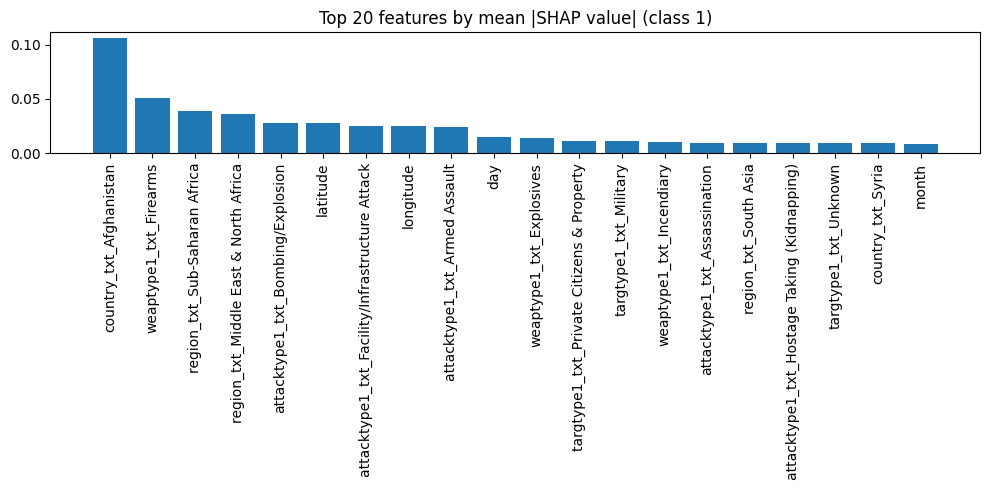

Fixed notebook not found at terrorism_project_fixed.ipynb - skipping append.

✅ Done — tuned model + SHAP explainability saved successfully.


In [2]:
import os, time, subprocess, sys, warnings
warnings.filterwarnings('ignore')

# 0) Ensure packages
reqs = ["pandas","numpy","scikit-learn","joblib","openpyxl","matplotlib","shap","nbformat", "streamlit"]
for pkg in reqs:
    pkg_to_import = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        __import__(pkg_to_import)
    except ImportError: # Catch ImportError specifically if package is not found or module path is wrong
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except Exception as e: # Catch other potential errors during import
        print(f"An unexpected error occurred while importing {pkg_to_import}: {e}")
        print(f"Attempting to install/upgrade {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    else:
        # If import succeeds, ensure it's upgraded, especially for scikit-learn, to get latest features/fixes
        if pkg == "scikit-learn":
            print(f"Upgrading {pkg} to ensure latest features/fixes...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])

# 1) Imports
import pandas as pd, numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import joblib, nbformat
from nbformat import v4
import shap

# 2) Paths
excel_path = os.path.join(os.getcwd(), 'globalterrorismdb_2021Jan-June_1222dist.xlsx')
fixed_nb_path = 'terrorism_project_fixed.ipynb'
out_model_path = 'rf_terror_model_full_tuned_shap.joblib'

# 3) Load data
print('Loading Excel file:', excel_path)
if not os.path.exists(excel_path):
    raise FileNotFoundError(f'Excel not found at {excel_path}')
df = pd.read_excel(excel_path, engine='openpyxl')
print('Loaded rows:', df.shape[0], 'cols:', df.shape[1])

# 4) Label & date features
df['fatal'] = (df.get('nkill', 0) > 0).astype(int)
if {'iyear','imonth','iday'}.issubset(df.columns):
    def make_date(r):
        try:
            return datetime(int(r['iyear']), int(max(1, int(r['imonth']))), int(max(1, int(r['iday']))))
        except Exception:
            return pd.NaT
    df['event_date'] = df.apply(make_date, axis=1)
    df['month'] = df['event_date'].dt.month.fillna(df.get('imonth',0)).astype(int)
    df['day'] = df['event_date'].dt.day.fillna(df.get('iday',0)).astype(int)
else:
    df['month'] = df.get('imonth',0)
    df['day'] = df.get('iday',0)

# 5) Categorical reduction (top-K)
cat_candidates = ['country_txt','region_txt','attacktype1_txt','targtype1_txt','weaptype1_txt','provstate','city']
cat_features = [c for c in cat_candidates if c in df.columns]
top_k = 20
for c in cat_features:
    top = df[c].value_counts().nlargest(top_k).index
    df[c] = df[c].where(df[c].isin(top), other='Other')
    df[c] = df[c].astype('category')

# 6) Feature selection (exclude nkill/nwound)
features_num = [c for c in ['latitude','longitude','month','day'] if c in df.columns]
features_cat = cat_features.copy()
print('Numeric features:', features_num)
print('Categorical features:', features_cat)

X = df[features_num + cat_features].copy()
y = df['fatal'].copy()
if features_num:
    X[features_num] = X[features_num].fillna(0).astype('float32')

# 7) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique()>1 else None)
print('Train/test shapes:', X_train.shape, X_test.shape)

# 8) Preprocessor & pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, features_num),
    ('cat', categorical_transformer, features_cat)
], remainder='drop')

# 9) Light tuning grid (fast & safe)
param_grid = [
    {'n_estimators':100, 'max_depth':None, 'min_samples_split':2, 'max_features':'sqrt'},
    {'n_estimators':150, 'max_depth':20,   'min_samples_split':5, 'max_features':'log2'},
    {'n_estimators':200, 'max_depth':30,   'min_samples_split':10,'max_features':0.5}
]

best_f1 = -1
best_model = None
best_cfg = None

for cfg in param_grid:
    print('Training cfg:', cfg)
    clf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=cfg['n_estimators'], max_depth=cfg['max_depth'],
            min_samples_split=cfg['min_samples_split'], max_features=cfg['max_features'],
            random_state=42, class_weight='balanced', n_jobs=1))
    ])
    t0 = time.time()
    clf.fit(X_train, y_train)
    t_elapsed = time.time() - t0
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f'  -> f1={f1:.4f}, time={t_elapsed:.1f}s')
    if f1 > best_f1:
        best_f1 = f1
        best_model = clf
        best_cfg = cfg

print('\nBest cfg:', best_cfg, 'best f1:', best_f1)

# 10) Evaluate best model
y_pred = best_model.predict(X_test)
print('\nAccuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (Best Model)')
plt.colorbar(); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.tight_layout(); plt.show()

# 11) Save tuned model
joblib.dump(best_model, out_model_path)
print('\nSaved tuned model to', out_model_path)

# 12) SHAP explainability
preproc = best_model.named_steps['preprocessor']
enc = preproc.named_transformers_['cat'].named_steps['onehot']
try:
    cat_names = list(enc.get_feature_names_out(features_cat))
except Exception:
    cat_names = []
    for i, feat in enumerate(features_cat):
        cats = enc.categories_[i]
        cat_names += [f"{feat}__{c}" for c in cats]
feature_names = features_num + cat_names
X_test_pre = preproc.transform(X_test)

explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_pre)

# SHAP summary (class 1)
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values[:, :, 1], X_test_pre, feature_names=feature_names, show=False)
plt.tight_layout(); plt.show()

# Top-20 SHAP features (bar)
shap_abs_mean = np.abs(shap_values[:, :, 1]).mean(axis=0)
idx = np.argsort(shap_abs_mean)[::-1][:20]
top_feats = [feature_names[i] for i in idx]
top_vals = shap_abs_mean[idx]
plt.figure(figsize=(10,5))
plt.bar(range(len(top_feats)), top_vals)
plt.xticks(range(len(top_feats)), top_feats, rotation=90)
plt.title('Top 20 features by mean |SHAP value| (class 1)')
plt.tight_layout(); plt.show()

# 13) Append summary to notebook (fixed version)
try:
    if os.path.exists(fixed_nb_path):
        summary_md = f"## Auto-added: Tuning & SHAP results\n\n- Tuned model saved: `{out_model_path}`\n- Best config: {best_cfg}\n- Best F1 (on test): {best_f1:.4f}\n"
        nb = nbformat.read(fixed_nb_path, as_version=4)
        nb.cells.append(v4.new_markdown_cell(summary_md))
        nbformat.write(nb, fixed_nb_path)
        print('Appended summary to', fixed_nb_path)
    else:
        print('Fixed notebook not found at', fixed_nb_path, '- skipping append.')
except Exception as e:
    print('Could not append to notebook:', e)

print('\n✅ Done — tuned model + SHAP explainability saved successfully.')

In [3]:
# ===========================================================
# ADVANCED STREAMLIT DASHBOARD FOR GTD PREDICTION + VISUALS
# ===========================================================
import subprocess, textwrap, os, sys # Added sys for sys.executable

app_code = textwrap.dedent('''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

MODEL_PATH = "rf_terror_model_full_tuned_shap.joblib"
DATA_PATH = "globalterrorismdb_2021Jan-June_1222dist.xlsx"

st.set_page_config(page_title="GTD Prediction & Visualization Dashboard", page_icon="💣", layout="wide")

st.title("💣 Global Terrorism Analysis & Fatality Prediction")
st.write("Explore trends, hotspots, and predict fatality likelihood using AI trained on the GTD dataset.")

# Load Data
@st.cache_data
def load_data():
    return pd.read_excel(DATA_PATH)

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

try:
    df = load_data()
    st.success(f"✅ Loaded dataset with {df.shape[0]:,} records")
except Exception as e:
    st.warning(f"⚠️ Could not load dataset: {e}")
    df = None

model = load_model()
preprocessor = model.named_steps['preprocessor']
classifier = model.named_steps['classifier']

# =======================
# SECTION 1: DATA VISUALS
# =======================
st.header("🌍 Global Terrorism Visualizations")
tab1, tab2, tab3 = st.tabs(["📊 Attack Overview", "🌎 World Heatmap", "📈 Regional Fatalities"])

with tab1:
    if df is not None:
        fig1 = px.pie(df, names='attacktype1_txt', title="Distribution of Attack Types", hole=0.4)
        st.plotly_chart(fig1, use_container_width=True)

with tab2:
    if df is not None and {'latitude','longitude'}.issubset(df.columns):
        df_map = df.dropna(subset=['latitude','longitude'])
        fig2 = px.density_mapbox(df_map, lat='latitude', lon='longitude', z=None,
                                 radius=5, center=dict(lat=20, lon=0),
                                 zoom=1, mapbox_style='carto-positron',
                                 title="Global Terror Attack Heatmap")
        st.plotly_chart(fig2, use_container_width=True)

with tab3:
    if df is not None and {'region_txt','nkill'}.issubset(df.columns):
        reg = df.groupby('region_txt')['nkill'].sum().reset_index()
        fig3 = px.bar(reg.sort_values('nkill', ascending=False),
                      x='region_txt', y='nkill',
                      title="Total Fatalities by Region",
                      color='nkill', color_continuous_scale='Reds')
        st.plotly_chart(fig3, use_container_width=True)

# ============================
# SECTION 2: PREDICTION + SHAP
# ============================
st.header("🎯 Predict Attack Fatality")
cat_features, num_features = [], []
for name, trans, cols in preprocessor.transformers_:
    if name == 'cat': cat_features = cols
    elif name == 'num': num_features = cols

col1, col2 = st.columns(2)
latitude = col1.number_input("Latitude", -90.0, 90.0, 20.0)
longitude = col2.number_input("Longitude", -180.0, 180.0, 77.0)
month = col1.slider("Month of Attack", 1, 12, 6)
day = col2.slider("Day of Attack", 1, 31, 15)

sample_df = pd.DataFrame({"latitude":[latitude], "longitude":[longitude], "month":[month], "day":[day]})

for cat in cat_features:
    try:
        cats = preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[cat_features.index(cat)]
        val = st.selectbox(cat.replace("_txt","").capitalize(), sorted(list(cats)))
        sample_df[cat] = [val]
    except Exception:
        sample_df[cat] = ["Other"]

pred = model.predict(sample_df)[0]
prob = model.predict_proba(sample_df)[0][1]
if pred == 1:
    st.error(f"☠️ Predicted: Fatal Attack (Probability: {prob:.2f})")
else:
    st.success(f"🕊️ Predicted: Non-Fatal Attack (Probability: {prob:.2f})")

# SHAP Feature Importance
st.subheader("🔍 Feature Importance (SHAP)")
X_trans = preprocessor.transform(sample_df)
explainer = shap.TreeExplainer(classifier)
shap_vals = explainer.shap_values(X_trans)

enc = preprocessor.named_transformers_['cat'].named_steps['onehot']
try:
    cat_names = list(enc.get_feature_names_out(cat_features))
except Exception:
    cat_names = []
    for i, feat in enumerate(cat_features):
        cat_names += [f"{feat}__{c}" for c in enc.categories_[i]]

feature_names = num_features + cat_names
shap_abs = np.abs(shap_vals[1]).flatten()
top_idx = np.argsort(shap_abs)[::-1][:10]
top_feats = [feature_names[i] for i in top_idx]
top_vals = shap_abs[top_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_feats[::-1], top_vals[::-1])
ax.set_xlabel("Mean |SHAP Value| (Impact)")
ax.set_title("Top 10 Influential Features")
st.pyplot(fig)

st.caption("Model trained on GTD dataset | Random Forest + SHAP explainability | Streamlit Dashboard by Ananya Pandey")
''')

with open("streamlit_gtd_dashboard.py", "w") as f:
    f.write(app_code)

subprocess.Popen([sys.executable, "-m", "streamlit", "run", "streamlit_gtd_dashboard.py"])
print("✅ Streamlit dashboard launching... check your terminal for the local URL (http://localhost:8501)")

✅ Streamlit dashboard launching... check your terminal for the local URL (http://localhost:8501)
